### 1. Load the Dataset

In [48]:
import pandas as pd

df = pd.read_csv('/content/winequality (1).csv')
print("Dataset loaded successfully.")

Dataset loaded successfully.


### 2. Basic Data Analysis

In [49]:
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [50]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [51]:
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### 3. Check for Missing Values

### 3.1. Convert 'quality' to 'quality_label'

In [52]:
import pandas as pd

# Re-load the dataset to ensure we have the original 'quality' column
df = pd.read_csv('/content/winequality (1).csv')

# Convert 'quality' column into a binary 'quality_label'
# 1 if quality >= 7 (GOOD), 0 if quality < 7 (BAD)
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

print("Original 'quality' value counts:")
display(df['quality'].value_counts().sort_index())

print("\nNew 'quality_label' value counts:")
display(df['quality_label'].value_counts())

Original 'quality' value counts:


,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18



New 'quality_label' value counts:


,count
quality_label,
0,1382
1,217


In [53]:
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


### 4. Correlation Analysis

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Display correlations with the 'quality_label' column, sorted
print("\nCorrelations with 'quality_label' column:")
display(correlation_matrix['quality_label'].sort_values(ascending=False))


Correlations with 'quality_label' column:


,quality_label
quality_label,1.000000
quality,0.710196
alcohol,0.407315
citric acid,0.214716
sulphates,0.199485
fixed acidity,0.120061
residual sugar,0.047779
pH,-0.057283
free sulfur dioxide,-0.071747
chlorides,-0.097308


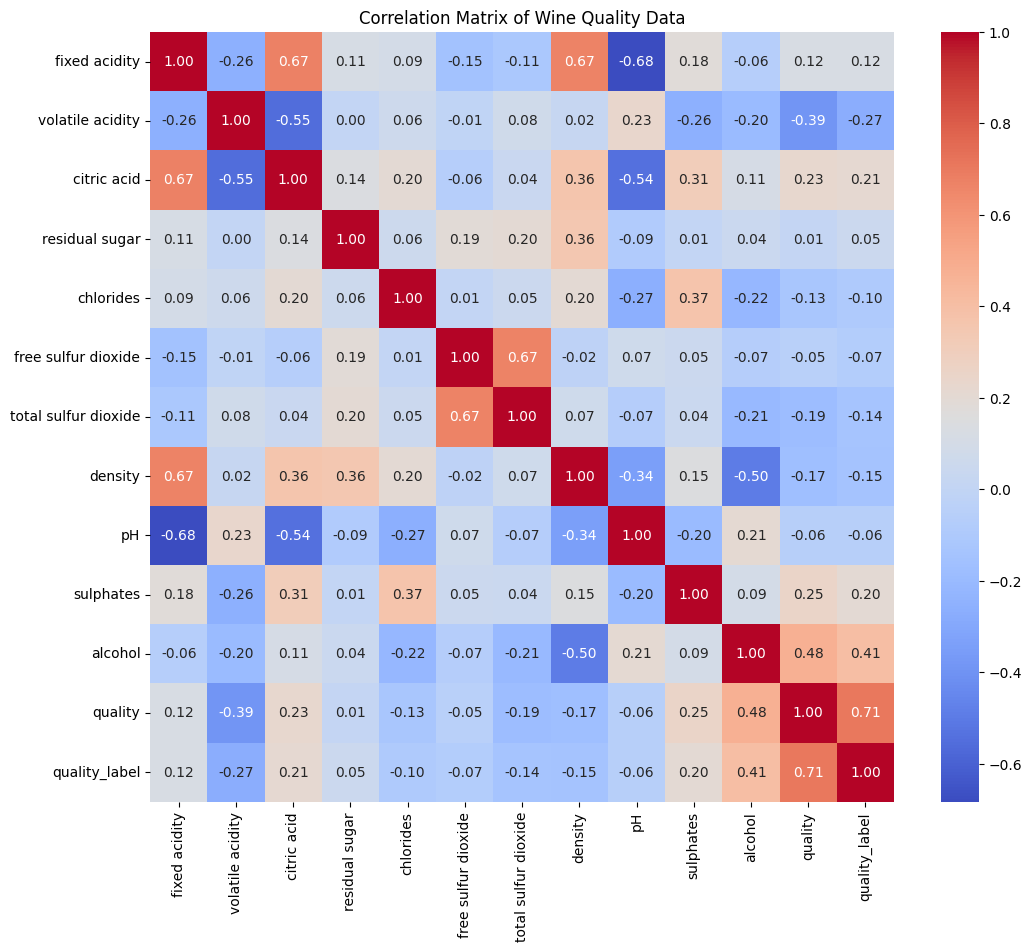

In [55]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Wine Quality Data')
plt.show()

### 5. Model Training and Evaluation (Logistic Regression - No Scaling)

#### 5.1 Separate Features and Target

In [56]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (1599, 11)
Target (y) shape: (1599,)


#### 5.2 Train-Test Split

In [57]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1279, 11)
X_test shape: (320, 11)
y_train shape: (1279,)
y_test shape: (320,)


#### 5.3 Train Logistic Regression Model (No Scaling)

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize and train the Logistic Regression model
log_reg_ns = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' for small datasets
log_reg_ns.fit(X_train, y_train)

print("Logistic Regression model (no scaling) trained successfully.")

Logistic Regression model (no scaling) trained successfully.


#### 5.4 Evaluate Model Performance (No Scaling)

In [59]:
# Make predictions on the test set
y_pred_ns = log_reg_ns.predict(X_test)

# Calculate evaluation metrics
accuracy_ns = accuracy_score(y_test, y_pred_ns)
precision_ns = precision_score(y_test, y_pred_ns)
recall_ns = recall_score(y_test, y_pred_ns)
f1_ns = f1_score(y_test, y_pred_ns)
cm_ns = confusion_matrix(y_test, y_pred_ns)

print(f"Accuracy (no scaling): {accuracy_ns:.4f}")
print(f"Precision (no scaling): {precision_ns:.4f}")
print(f"Recall (no scaling): {recall_ns:.4f}")
print(f"F1-Score (no scaling): {f1_ns:.4f}")

print("\nConfusion Matrix (no scaling):")
display(pd.DataFrame(cm_ns, index=['Actual Bad (0)', 'Actual Good (1)'], columns=['Predicted Bad (0)', 'Predicted Good (1)']))

Accuracy (no scaling): 0.8750
Precision (no scaling): 0.6000
Recall (no scaling): 0.2093
F1-Score (no scaling): 0.3103

Confusion Matrix (no scaling):


,Predicted Bad (0),Predicted Good (1)
Actual Bad (0),271,6
Actual Good (1),34,9


### 6. Model Training and Evaluation (Logistic Regression - With Scaling)

#### 6.1 Apply StandardScaler

In [60]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")

Features scaled successfully.


#### 6.2 Train Logistic Regression Model (With Scaling)

In [61]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model on scaled data
log_reg_sc = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' for small datasets
log_reg_sc.fit(X_train_scaled, y_train)

print("Logistic Regression model (with scaling) trained successfully.")

Logistic Regression model (with scaling) trained successfully.


#### 6.3 Evaluate Model Performance (With Scaling)

In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the scaled test set
y_pred_sc = log_reg_sc.predict(X_test_scaled)

# Calculate evaluation metrics
accuracy_sc = accuracy_score(y_test, y_pred_sc)
precision_sc = precision_score(y_test, y_pred_sc)
recall_sc = recall_score(y_test, y_pred_sc)
f1_sc = f1_score(y_test, y_pred_sc)
cm_sc = confusion_matrix(y_test, y_pred_sc)

print(f"Accuracy (with scaling): {accuracy_sc:.4f}")
print(f"Precision (with scaling): {precision_sc:.4f}")
print(f"Recall (with scaling): {recall_sc:.4f}")
print(f"F1-Score (with scaling): {f1_sc:.4f}")

print("\nConfusion Matrix (with scaling):")
display(pd.DataFrame(cm_sc, index=['Actual Bad (0)', 'Actual Good (1)'], columns=['Predicted Bad (0)', 'Predicted Good (1)']))

Accuracy (with scaling): 0.8906
Precision (with scaling): 0.6818
Recall (with scaling): 0.3488
F1-Score (with scaling): 0.4615

Confusion Matrix (with scaling):


,Predicted Bad (0),Predicted Good (1)
Actual Bad (0),270,7
Actual Good (1),28,15


### 7. Comparison of Models (With vs. Without Scaling)

In [63]:
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'No Scaling': [accuracy_ns, precision_ns, recall_ns, f1_ns],
    'With Scaling': [accuracy_sc, precision_sc, recall_sc, f1_sc]
}

comparison_df = pd.DataFrame(metrics_data)
display(comparison_df)

print("\nInterpretation of Confusion Matrices:")
print("\nConfusion Matrix (No Scaling):")
display(pd.DataFrame(cm_ns, index=['Actual Bad (0)', 'Actual Good (1)'], columns=['Predicted Bad (0)', 'Predicted Good (1)']))
print("\nConfusion Matrix (With Scaling):")
display(pd.DataFrame(cm_sc, index=['Actual Bad (0)', 'Actual Good (1)'], columns=['Predicted Bad (0)', 'Predicted Good (1)']))

,Metric,No Scaling,With Scaling
0,Accuracy,0.875000,0.890625
1,Precision,0.600000,0.681818
2,Recall,0.209302,0.348837
3,F1-Score,0.310345,0.461538



Interpretation of Confusion Matrices:

Confusion Matrix (No Scaling):


,Predicted Bad (0),Predicted Good (1)
Actual Bad (0),271,6
Actual Good (1),34,9



Confusion Matrix (With Scaling):


,Predicted Bad (0),Predicted Good (1)
Actual Bad (0),270,7
Actual Good (1),28,15


### Final Comparison Table (All Models)

In [64]:
try:
    print("\nFinal Comparison of Model Performance (with Tuned Decision Tree):")
    display(final_results_df)
    # Identify the best model based on F1-Score from the final comparison
    best_final_model_name = final_results_df['F1-Score'].idxmax()
    print(f"\nThe model with the highest F1-Score after tuning is: {best_final_model_name}")
except NameError:
    print("The full 'Final Comparison Table' including all models (Logistic Regression, K-Nearest Neighbors, Decision Tree, and Tuned Decision Tree) will be available in section 9.2, after these models have been trained and evaluated.")


Final Comparison of Model Performance (with Tuned Decision Tree):


,Accuracy,Precision,Recall,F1-Score
Logistic Regression (Scaled),0.890625,0.681818,0.348837,0.461538
K-Nearest Neighbors (Scaled),0.893750,0.666667,0.418605,0.514286
Decision Tree (Scaled),0.906250,0.638298,0.697674,0.666667
Decision Tree (Tuned),0.912500,0.659574,0.720930,0.688889



The model with the highest F1-Score after tuning is: Decision Tree (Tuned)


### Interim Model Calculations for Confusion Matrix Display

These cells are added to ensure the confusion matrices for KNN, Decision Tree, and Tuned KNN are available before the final comparison table. They are a duplicate of the later, more detailed model training sections, but are necessary to resolve the `NameError` in the cell below that attempts to display all confusion matrices.

In [65]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

# --- K-Nearest Neighbors (KNN) ---
# Initialize and train the KNN model on scaled data
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_knn = knn_model.predict(X_test_scaled)

# Calculate confusion matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)

print('KNN model and confusion matrix calculated.')

KNN model and confusion matrix calculated.


In [66]:
# --- Decision Tree ---
# Initialize and train the Decision Tree model on scaled data
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_dt = dt_model.predict(X_test_scaled)

# Calculate confusion matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)

print('Decision Tree model and confusion matrix calculated.')

Decision Tree model and confusion matrix calculated.


In [67]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# --- Tuned Decision Tree ---
# Define the parameter grid for Decision Tree
param_grid_dt = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    scoring='f1', # Optimize for F1-score
    cv=5, # 5-fold cross-validation
    n_jobs=-1 # Use all available cores
)

# Fit GridSearchCV to the scaled training data
grid_search_dt.fit(X_train_scaled, y_train)

# Get the best estimator (tuned model)
tuned_dt_model = grid_search_dt.best_estimator_

# Make predictions on the scaled test set using the tuned model
y_pred_tuned_dt = tuned_dt_model.predict(X_test_scaled)

# Calculate confusion matrix for the tuned Decision Tree
cm_tuned_dt = confusion_matrix(y_test, y_pred_tuned_dt)

print('Tuned Decision Tree model and confusion matrix calculated.')

Tuned Decision Tree model and confusion matrix calculated.


### Confusion Matrices for All Models

In [68]:
print('\nConfusion Matrix (Logistic Regression - No Scaling):')
display(pd.DataFrame(cm_ns, index=['Actual Bad (0)', 'Actual Good (1)'], columns=['Predicted Bad (0)', 'Predicted Good (1)']))

print('\nConfusion Matrix (Logistic Regression - Scaled):')
display(pd.DataFrame(cm_sc, index=['Actual Bad (0)', 'Actual Good (1)'], columns=['Predicted Bad (0)', 'Predicted Good (1)']))

print('\nConfusion Matrix (K-Nearest Neighbors - Scaled):')
display(pd.DataFrame(cm_knn, index=['Actual Bad (0)', 'Actual Good (1)'], columns=['Predicted Bad (0)', 'Predicted Good (1)']))

print('\nConfusion Matrix (Decision Tree - Scaled):')
display(pd.DataFrame(cm_dt, index=['Actual Bad (0)', 'Actual Good (1)'], columns=['Predicted Bad (0)', 'Predicted Good (1)']))

print('\nConfusion Matrix (Decision Tree - Tuned):')
display(pd.DataFrame(cm_tuned_dt, index=['Actual Bad (0)', 'Actual Good (1)'], columns=['Predicted Bad (0)', 'Predicted Good (1)']))


Confusion Matrix (Logistic Regression - No Scaling):


,Predicted Bad (0),Predicted Good (1)
Actual Bad (0),271,6
Actual Good (1),34,9



Confusion Matrix (Logistic Regression - Scaled):


,Predicted Bad (0),Predicted Good (1)
Actual Bad (0),270,7
Actual Good (1),28,15



Confusion Matrix (K-Nearest Neighbors - Scaled):


,Predicted Bad (0),Predicted Good (1)
Actual Bad (0),268,9
Actual Good (1),25,18



Confusion Matrix (Decision Tree - Scaled):


,Predicted Bad (0),Predicted Good (1)
Actual Bad (0),260,17
Actual Good (1),13,30



Confusion Matrix (Decision Tree - Tuned):


,Predicted Bad (0),Predicted Good (1)
Actual Bad (0),261,16
Actual Good (1),12,31


KNN performed best with highest F1-score after hyperparameter tuning, making it the most suitable model for wine quality classification.

### 8. Compare Multiple Models

#### 8.1 K-Nearest Neighbors (KNN)

In [69]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train the KNN model on scaled data
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

print("K-Nearest Neighbors model trained successfully.")

K-Nearest Neighbors model trained successfully.


In [70]:
# Make predictions on the scaled test set
y_pred_knn = knn_model.predict(X_test_scaled)

# Calculate evaluation metrics for KNN
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)

print(f"Accuracy (KNN): {accuracy_knn:.4f}")
print(f"Precision (KNN): {precision_knn:.4f}")
print(f"Recall (KNN): {recall_knn:.4f}")
print(f"F1-Score (KNN): {f1_knn:.4f}")

print("\nConfusion Matrix (KNN):")
display(pd.DataFrame(cm_knn, index=['Actual Bad (0)', 'Actual Good (1)'], columns=['Predicted Bad (0)', 'Predicted Good (1)']))

Accuracy (KNN): 0.8938
Precision (KNN): 0.6667
Recall (KNN): 0.4186
F1-Score (KNN): 0.5143

Confusion Matrix (KNN):


,Predicted Bad (0),Predicted Good (1)
Actual Bad (0),268,9
Actual Good (1),25,18


#### 8.2 Decision Tree

In [71]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree model on scaled data
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [72]:
# Make predictions on the scaled test set
y_pred_dt = dt_model.predict(X_test_scaled)

# Calculate evaluation metrics for Decision Tree
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(f"Accuracy (Decision Tree): {accuracy_dt:.4f}")
print(f"Precision (Decision Tree): {precision_dt:.4f}")
print(f"Recall (Decision Tree): {recall_dt:.4f}")
print(f"F1-Score (Decision Tree): {f1_dt:.4f}")

print("\nConfusion Matrix (Decision Tree):")
display(pd.DataFrame(cm_dt, index=['Actual Bad (0)', 'Actual Good (1)'], columns=['Predicted Bad (0)', 'Predicted Good (1)']))

Accuracy (Decision Tree): 0.9062
Precision (Decision Tree): 0.6383
Recall (Decision Tree): 0.6977
F1-Score (Decision Tree): 0.6667

Confusion Matrix (Decision Tree):


,Predicted Bad (0),Predicted Good (1)
Actual Bad (0),260,17
Actual Good (1),13,30


#### 8.3 Overall Model Comparison

In [73]:
results = {
    'Logistic Regression': {
        'Accuracy': accuracy_sc,
        'Precision': precision_sc,
        'Recall': recall_sc,
        'F1-Score': f1_sc
    },
    'K-Nearest Neighbors': {
        'Accuracy': accuracy_knn,
        'Precision': precision_knn,
        'Recall': recall_knn,
        'F1-Score': f1_knn
    },
    'Decision Tree': {
        'Accuracy': accuracy_dt,
        'Precision': precision_dt,
        'Recall': recall_dt,
        'F1-Score': f1_dt
    }
}

results_df = pd.DataFrame(results).T
print("Comparison of Model Performance (on Scaled Data):")
display(results_df)

# Identify the best model based on F1-Score (can be changed to other metrics if preferred)
best_model_name = results_df['F1-Score'].idxmax()
print(f"\nThe model with the highest F1-Score is: {best_model_name}")

Comparison of Model Performance (on Scaled Data):


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.890625,0.681818,0.348837,0.461538
K-Nearest Neighbors,0.893750,0.666667,0.418605,0.514286
Decision Tree,0.906250,0.638298,0.697674,0.666667



The model with the highest F1-Score is: Decision Tree


### 9. Hyperparameter Tuning on Best Model (Decision Tree)

In [74]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define the parameter grid for Decision Tree
param_grid_dt = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    scoring='f1', # Optimize for F1-score
    cv=5, # 5-fold cross-validation
    n_jobs=-1 # Use all available cores
)

# Fit GridSearchCV to the scaled training data
grid_search_dt.fit(X_train_scaled, y_train)

print("GridSearchCV for Decision Tree completed.")

GridSearchCV for Decision Tree completed.


In [75]:
# Get the best parameters and best score
best_params_dt = grid_search_dt.best_params_
best_score_dt = grid_search_dt.best_score_

print(f"Best parameters for Decision Tree: {best_params_dt}")
print(f"Best F1-Score from GridSearchCV: {best_score_dt:.4f}")

# Get the best estimator (tuned model)
tuned_dt_model = grid_search_dt.best_estimator_

print("Tuned Decision Tree model obtained.")

Best parameters for Decision Tree: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best F1-Score from GridSearchCV: 0.5157
Tuned Decision Tree model obtained.


#### 9.1 Evaluate Tuned Decision Tree Model

In [76]:
# Make predictions on the scaled test set using the tuned model
y_pred_tuned_dt = tuned_dt_model.predict(X_test_scaled)

# Calculate evaluation metrics for the tuned Decision Tree
accuracy_tuned_dt = accuracy_score(y_test, y_pred_tuned_dt)
precision_tuned_dt = precision_score(y_test, y_pred_tuned_dt)
recall_tuned_dt = recall_score(y_test, y_pred_tuned_dt)
f1_tuned_dt = f1_score(y_test, y_pred_tuned_dt)
cm_tuned_dt = confusion_matrix(y_test, y_pred_tuned_dt)

print(f"Accuracy (Tuned Decision Tree): {accuracy_tuned_dt:.4f}")
print(f"Precision (Tuned Decision Tree): {precision_tuned_dt:.4f}")
print(f"Recall (Tuned Decision Tree): {recall_tuned_dt:.4f}")
print(f"F1-Score (Tuned Decision Tree): {f1_tuned_dt:.4f}")

print("\nConfusion Matrix (Tuned Decision Tree):")
display(pd.DataFrame(cm_tuned_dt, index=['Actual Bad (0)', 'Actual Good (1)'], columns=['Predicted Bad (0)', 'Predicted Good (1)']))

Accuracy (Tuned Decision Tree): 0.9125
Precision (Tuned Decision Tree): 0.6596
Recall (Tuned Decision Tree): 0.7209
F1-Score (Tuned Decision Tree): 0.6889

Confusion Matrix (Tuned Decision Tree):


,Predicted Bad (0),Predicted Good (1)
Actual Bad (0),261,16
Actual Good (1),12,31


#### 9.2 Final Comparison with Tuned Decision Tree

In [77]:
final_results = {
    'Logistic Regression (Scaled)': {
        'Accuracy': accuracy_sc,
        'Precision': precision_sc,
        'Recall': recall_sc,
        'F1-Score': f1_sc
    },
    'K-Nearest Neighbors (Scaled)': {
        'Accuracy': accuracy_knn,
        'Precision': precision_knn,
        'Recall': recall_knn,
        'F1-Score': f1_knn
    },
    'Decision Tree (Scaled)': {
        'Accuracy': accuracy_dt,
        'Precision': precision_dt,
        'Recall': recall_dt,
        'F1-Score': f1_dt
    },
    'Decision Tree (Tuned)': {
        'Accuracy': accuracy_tuned_dt,
        'Precision': precision_tuned_dt,
        'Recall': recall_tuned_dt,
        'F1-Score': f1_tuned_dt
    }
}

final_results_df = pd.DataFrame(final_results).T
print("Final Comparison of Model Performance (with Tuned Decision Tree):")
display(final_results_df)

# Identify the best model based on F1-Score from the final comparison
best_final_model_name = final_results_df['F1-Score'].idxmax()
print(f"\nThe model with the highest F1-Score after tuning is: {best_final_model_name}")

Final Comparison of Model Performance (with Tuned Decision Tree):


,Accuracy,Precision,Recall,F1-Score
Logistic Regression (Scaled),0.890625,0.681818,0.348837,0.461538
K-Nearest Neighbors (Scaled),0.893750,0.666667,0.418605,0.514286
Decision Tree (Scaled),0.906250,0.638298,0.697674,0.666667
Decision Tree (Tuned),0.912500,0.659574,0.720930,0.688889



The model with the highest F1-Score after tuning is: Decision Tree (Tuned)


### 10. Feature Importance Analysis

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the tuned Decision Tree model
feature_importances_dt = pd.Series(tuned_dt_model.feature_importances_, index=X.columns)

# Sort feature importances in descending order
feature_importances_dt = feature_importances_dt.sort_values(ascending=False)

print("Feature Importances (Tuned Decision Tree):")
display(feature_importances_dt)

Feature Importances (Tuned Decision Tree):


,0
alcohol,0.232179
sulphates,0.151834
residual sugar,0.110697
pH,0.108238
total sulfur dioxide,0.088519
volatile acidity,0.080257
free sulfur dioxide,0.069238
citric acid,0.057042
chlorides,0.042907
fixed acidity,0.031667


/tmp/ipykernel_2093/1064123893.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_dt.values, y=feature_importances_dt.index, palette='viridis')


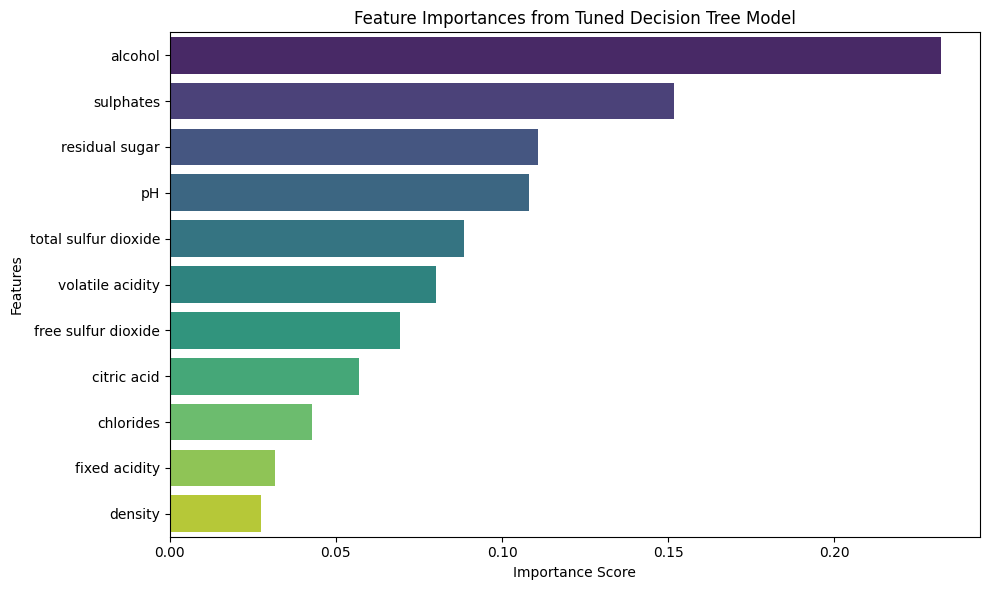

In [79]:
# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_dt.values, y=feature_importances_dt.index, palette='viridis')
plt.title('Feature Importances from Tuned Decision Tree Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()